# Feature Engineering

Baseado nos insights do `01_eda.ipynb`, este notebook transforma os dados brutos em um dataset limpo e pronto para treinar os modelos de Machine Learning.

**Objetivo:** Prever se um voo vai atrasar (**IS_DELAYED = 1** se ARRIVAL_DELAY ≥ 15 min).

**Premissa importante:** Usamos apenas features **pré-voo** — informações disponíveis antes do avião decolar. Colunas de runtime (DEPARTURE_DELAY, TAXI_OUT, etc.) são excluídas para evitar excesso de dados desnecessarios que podem comprometer a performance do modelo.

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Imports OK')

Imports OK


## 2. Leitura dos Dados Brutos

In [2]:
df = pd.read_csv('../data/raw/flights.csv', low_memory=False)
df_airlines = pd.read_csv('../data/raw/airlines.csv')
df_airports = pd.read_csv('../data/raw/airports.csv')

print(f'Voos brutos:    {len(df):>10,}')
print(f'Companhias:     {len(df_airlines):>10,}')
print(f'Aeroportos:     {len(df_airports):>10}')
print(f'\nColunas: {df.columns.tolist()}')

Voos brutos:     5,819,079
Companhias:             14
Aeroportos:            322

Colunas: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


## 3. Filtro: Remover Cancelamentos e Desvios

Voos cancelados e desviados não possuem `ARRIVAL_DELAY`, portanto não fazem parte do escopo do modelo de atraso.

In [3]:
df = df[
    (df['CANCELLED'] == 0) &
    (df['DIVERTED'] == 0) &
    (df['ARRIVAL_DELAY'].notna())
].copy()

# Garantir tipos corretos nos aeroportos (coluna tem tipos mistos)
df['ORIGIN_AIRPORT'] = df['ORIGIN_AIRPORT'].astype(str)
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].astype(str)

print(f'Voos após filtro: {len(df):,}')

Voos após filtro: 5,714,008


## 4. Criação da Variável Alvo: IS_DELAYED

Critério FAA: atraso na chegada **>= 15 minutos** = ATRASADO.

In [4]:
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] >= 15).astype(int)

print('Distribuição da variável alvo:')
vc = df['IS_DELAYED'].value_counts()
print(f'  Pontual  (0): {vc[0]:>10,}  ({vc[0]/len(df)*100:.2f}%)')
print(f'  Atrasado (1): {vc[1]:>10,}  ({vc[1]/len(df)*100:.2f}%)')

Distribuição da variável alvo:
  Pontual  (0):  4,650,569  (81.39%)
  Atrasado (1):  1,063,439  (18.61%)


## 5. Remoção de Colunas Irrelevantes ou com Data Leakage

| Coluna(s) | Motivo da Remoção |
|-----------|-------------------|
| `YEAR` | Constante (todos 2015) — sem poder preditivo |
| `FLIGHT_NUMBER` | Identificador, não é feature preditiva |
| `TAIL_NUMBER` | Alta cardinalidade, 0.25% nulos, não disponível pré-voo |
| `DEPARTURE_TIME`, `DEPARTURE_DELAY`, `TAXI_OUT`, `WHEELS_OFF` | Runtime — disponíveis só após decolagem |
| `ELAPSED_TIME`, `AIR_TIME`, `WHEELS_ON`, `TAXI_IN`, `ARRIVAL_TIME` | Runtime — disponíveis só após pouso |
| `ARRIVAL_DELAY` | Target original — removida para evitar leakage |
| `DIVERTED`, `CANCELLED` | Sempre 0 após o filtro |
| `CANCELLATION_REASON` | Só preenchida em cancelamentos — irrelevante |
| `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY` | Causas de atraso — informação pós-voo, ~81% nulos |

In [5]:
columns_to_drop = [
    # Sem variação
    'YEAR',
    # Identificadores
    'FLIGHT_NUMBER', 'TAIL_NUMBER',
    # Runtime pos-decolagem
    'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
    # Runtime pos-pouso
    'ELAPSED_TIME', 'AIR_TIME', 'WHEELS_ON', 'TAXI_IN', 'ARRIVAL_TIME',
    # Target original + flags de status
    'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
    # Causas de atraso (pos-voo)
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY',
]

df.drop(columns=columns_to_drop, inplace=True)

print(f'Colunas restantes ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}')

Colunas restantes (11):
  MONTH: int64
  DAY: int64
  DAY_OF_WEEK: int64
  AIRLINE: str
  ORIGIN_AIRPORT: str
  DESTINATION_AIRPORT: str
  SCHEDULED_DEPARTURE: int64
  SCHEDULED_TIME: float64
  DISTANCE: int64
  SCHEDULED_ARRIVAL: int64
  IS_DELAYED: int64


## 6. Engenharia de Features Temporais

As colunas `SCHEDULED_DEPARTURE` e `SCHEDULED_ARRIVAL` estão no formato HHMM (ex: 1305 = 13h05). Vamos extrair a **hora** como feature numérica, que é mais informativa para o modelo do que o inteiro HHMM.

In [6]:
# Hora da partida programada (0-23)
df['SCHED_DEP_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

# Hora da chegada programada (0-23)
df['SCHED_ARR_HOUR'] = (df['SCHEDULED_ARRIVAL'] // 100).astype(int)

# Remover as colunas HHMM originais
df.drop(columns=['SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL'], inplace=True)

print('Features temporais criadas:')
print(f'  SCHED_DEP_HOUR  range: {df["SCHED_DEP_HOUR"].min()} a {df["SCHED_DEP_HOUR"].max()}')
print(f'  SCHED_ARR_HOUR  range: {df["SCHED_ARR_HOUR"].min()} a {df["SCHED_ARR_HOUR"].max()}')

Features temporais criadas:
  SCHED_DEP_HOUR  range: 0 a 23
  SCHED_ARR_HOUR  range: 0 a 24


## 7. Tratamento de Valores Nulos

Após remover as colunas de runtime, os únicos nulos restantes são em `SCHEDULED_TIME` (apenas 6 registros).

In [7]:
# Verificar nulos restantes
nulos = df.isnull().sum()
nulos_existentes = nulos[nulos > 0]
print('Nulos restantes:')
print(nulos_existentes if len(nulos_existentes) > 0 else '  Nenhum nulo encontrado!')

# SCHEDULED_TIME: preencher com a mediana
if df['SCHEDULED_TIME'].isnull().sum() > 0:
    median_sched = df['SCHEDULED_TIME'].median()
    df['SCHEDULED_TIME'].fillna(median_sched, inplace=True)
    print(f'\nSCHEDULED_TIME: nulos preenchidos com mediana ({median_sched:.0f} min)')

print(f'\nNulos apos tratamento: {df.isnull().sum().sum()}')

Nulos restantes:
  Nenhum nulo encontrado!

Nulos apos tratamento: 0


## 8. Enriquecimento com Dados de Aeroportos

Adicionamos o **Estado (STATE)** de origem e destino como feature geográfica.

In [8]:
# Preparar tabela de aeroportos
airport_info = df_airports[['IATA_CODE', 'STATE']].copy()
airport_info['IATA_CODE'] = airport_info['IATA_CODE'].astype(str)

# Merge: estado de origem
df = df.merge(
    airport_info.rename(columns={'IATA_CODE': 'ORIGIN_AIRPORT', 'STATE': 'ORIGIN_STATE'}),
    on='ORIGIN_AIRPORT', how='left'
)

# Merge: estado de destino
df = df.merge(
    airport_info.rename(columns={'IATA_CODE': 'DESTINATION_AIRPORT', 'STATE': 'DEST_STATE'}),
    on='DESTINATION_AIRPORT', how='left'
)

# Preencher aeroportos sem estado (codigos numericos internacionais)
df['ORIGIN_STATE'].fillna('UNKNOWN', inplace=True)
df['DEST_STATE'].fillna('UNKNOWN', inplace=True)

print(f'Estados de origem unicos: {df["ORIGIN_STATE"].nunique()}')
print(f'Estados de destino unicos: {df["DEST_STATE"].nunique()}')

Estados de origem unicos: 54
Estados de destino unicos: 54


## 9. Target Encodings Combinados

Features novas de alta relevância preditiva — capturam padrões históricos de atraso em combinações mais granulares que os aeroportos isolados:

| Feature | Agrupamento | Por que é mais informativa |
|---------|-------------|---------------------------|
| `ROUTE_DELAY_RATE` | origem × destino | Captura gargalos estruturais de rota |
| `AIRLINE_ORIGIN_DELAY_RATE` | companhia × aeroporto origem | Algumas companhias são piores em aeroportos específicos |
| `HOUR_ORIGIN_DELAY_RATE` | hora × aeroporto origem | Congestionamento varia por horário no mesmo aeroporto |

In [9]:
global_delay_mean = df['IS_DELAYED'].mean()

# --- ROUTE_DELAY_RATE: taxa histórica por rota (origem → destino) ---
route_delay_rate = (
    df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['IS_DELAYED']
    .mean()
    .rename('ROUTE_DELAY_RATE')
    .reset_index()
)
df = df.merge(route_delay_rate, on=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'], how='left')

# --- AIRLINE_ORIGIN_DELAY_RATE: taxa histórica por companhia × aeroporto de origem ---
airline_origin_rate = (
    df.groupby(['AIRLINE', 'ORIGIN_AIRPORT'])['IS_DELAYED']
    .mean()
    .rename('AIRLINE_ORIGIN_DELAY_RATE')
    .reset_index()
)
df = df.merge(airline_origin_rate, on=['AIRLINE', 'ORIGIN_AIRPORT'], how='left')

# --- HOUR_ORIGIN_DELAY_RATE: taxa histórica por hora de partida × aeroporto de origem ---
hour_origin_rate = (
    df.groupby(['SCHED_DEP_HOUR', 'ORIGIN_AIRPORT'])['IS_DELAYED']
    .mean()
    .rename('HOUR_ORIGIN_DELAY_RATE')
    .reset_index()
)
df = df.merge(hour_origin_rate, on=['SCHED_DEP_HOUR', 'ORIGIN_AIRPORT'], how='left')

# Preencher eventuais NaN com a média global (rotas/combinações com poucos voos)
df['ROUTE_DELAY_RATE'].fillna(global_delay_mean, inplace=True)
df['AIRLINE_ORIGIN_DELAY_RATE'].fillna(global_delay_mean, inplace=True)
df['HOUR_ORIGIN_DELAY_RATE'].fillna(global_delay_mean, inplace=True)

print(f'3 features criadas:')
print(f'  ROUTE_DELAY_RATE           range: {df["ROUTE_DELAY_RATE"].min():.3f} – {df["ROUTE_DELAY_RATE"].max():.3f}  |  únicos: {df["ROUTE_DELAY_RATE"].nunique()}')
print(f'  AIRLINE_ORIGIN_DELAY_RATE  range: {df["AIRLINE_ORIGIN_DELAY_RATE"].min():.3f} – {df["AIRLINE_ORIGIN_DELAY_RATE"].max():.3f}  |  únicos: {df["AIRLINE_ORIGIN_DELAY_RATE"].nunique()}')
print(f'  HOUR_ORIGIN_DELAY_RATE     range: {df["HOUR_ORIGIN_DELAY_RATE"].min():.3f} – {df["HOUR_ORIGIN_DELAY_RATE"].max():.3f}  |  únicos: {df["HOUR_ORIGIN_DELAY_RATE"].nunique()}')
print(f'\nNulos: {df[["ROUTE_DELAY_RATE","AIRLINE_ORIGIN_DELAY_RATE","HOUR_ORIGIN_DELAY_RATE"]].isnull().sum().sum()}')

3 features criadas:
  ROUTE_DELAY_RATE           range: 0.000 – 1.000  |  únicos: 5106
  AIRLINE_ORIGIN_DELAY_RATE  range: 0.000 – 1.000  |  únicos: 1969
  HOUR_ORIGIN_DELAY_RATE     range: 0.000 – 1.000  |  únicos: 3879

Nulos: 0


## 10. Encoding de Variáveis Categóricas

| Variável | Cardinalidade | Estratégia |
|----------|--------------|------------|
| `AIRLINE` | 14 | **Label Encoding** — baixa cardinalidade |
| `ORIGIN_AIRPORT` | ~300+ | **Target Encoding** — taxa histórica de atraso por aeroporto |
| `DESTINATION_AIRPORT` | ~300+ | **Target Encoding** — taxa histórica de atraso por aeroporto |
| `ORIGIN_STATE` / `DEST_STATE` | ~55 | **Label Encoding** |

> As features combinadas (`ROUTE_DELAY_RATE`, `AIRLINE_ORIGIN_DELAY_RATE`, `HOUR_ORIGIN_DELAY_RATE`) já foram calculadas na seção anterior enquanto os identificadores originais ainda estavam disponíveis.

In [10]:
# --- AIRLINE: Label Encoding ---
le_airline = LabelEncoder()
df['AIRLINE_ENC'] = le_airline.fit_transform(df['AIRLINE'])

airline_map = dict(zip(le_airline.classes_, le_airline.transform(le_airline.classes_)))
print('Mapeamento AIRLINE_ENC:')
for k, v in sorted(airline_map.items(), key=lambda x: x[1]):
    print(f'  {v:2d} -> {k}')

df.drop(columns=['AIRLINE'], inplace=True)

Mapeamento AIRLINE_ENC:
   0 -> AA
   1 -> AS
   2 -> B6
   3 -> DL
   4 -> EV
   5 -> F9
   6 -> HA
   7 -> MQ
   8 -> NK
   9 -> OO
  10 -> UA
  11 -> US
  12 -> VX
  13 -> WN


In [11]:
# --- ORIGIN_AIRPORT e DESTINATION_AIRPORT: Target Encoding ---
# Taxa historica de atraso por aeroporto

origin_delay_rate = (
    df.groupby('ORIGIN_AIRPORT')['IS_DELAYED']
    .mean()
    .rename('ORIGIN_DELAY_RATE')
    .reset_index()
)

dest_delay_rate = (
    df.groupby('DESTINATION_AIRPORT')['IS_DELAYED']
    .mean()
    .rename('DEST_DELAY_RATE')
    .reset_index()
)

df = df.merge(origin_delay_rate, on='ORIGIN_AIRPORT', how='left')
df = df.merge(dest_delay_rate, on='DESTINATION_AIRPORT', how='left')

df.drop(columns=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'], inplace=True)

print(f'ORIGIN_DELAY_RATE  range: {df["ORIGIN_DELAY_RATE"].min():.3f} a {df["ORIGIN_DELAY_RATE"].max():.3f}')
print(f'DEST_DELAY_RATE    range: {df["DEST_DELAY_RATE"].min():.3f} a {df["DEST_DELAY_RATE"].max():.3f}')

ORIGIN_DELAY_RATE  range: 0.000 a 0.556
DEST_DELAY_RATE    range: 0.000 a 0.438


In [12]:
# --- ORIGIN_STATE e DEST_STATE: Label Encoding ---
le_state = LabelEncoder()

# Fit em todos os estados possiveis (origem + destino juntos)
all_states = pd.concat([
    df['ORIGIN_STATE'], df['DEST_STATE']
]).unique()
le_state.fit(all_states)

df['ORIGIN_STATE_ENC'] = le_state.transform(df['ORIGIN_STATE'])
df['DEST_STATE_ENC'] = le_state.transform(df['DEST_STATE'])

df.drop(columns=['ORIGIN_STATE', 'DEST_STATE'], inplace=True)

print(f'Estados unicos encodados: {len(le_state.classes_)}')
print(f'ORIGIN_STATE_ENC  range: {df["ORIGIN_STATE_ENC"].min()} a {df["ORIGIN_STATE_ENC"].max()}')

Estados unicos encodados: 55
ORIGIN_STATE_ENC  range: 0 a 54


## 11. Dataset Final: Visão Geral

In [13]:
print('=' * 60)
print(f'Shape final: {df.shape}')
print('=' * 60)
print('\nColunas e tipos:')
for col in df.columns:
    print(f'  {col:<22} {str(df[col].dtype):<10} nulos: {df[col].isnull().sum()}')

print(f'\nNulos totais: {df.isnull().sum().sum()}')
print(f'\nDistribuicao da target IS_DELAYED:')
vc = df['IS_DELAYED'].value_counts()
print(f'  0 (Pontual):  {vc[0]:>10,}  ({vc[0]/len(df)*100:.2f}%)')
print(f'  1 (Atrasado): {vc[1]:>10,}  ({vc[1]/len(df)*100:.2f}%)')

Shape final: (5714008, 16)

Colunas e tipos:
  MONTH                  int64      nulos: 0
  DAY                    int64      nulos: 0
  DAY_OF_WEEK            int64      nulos: 0
  SCHEDULED_TIME         float64    nulos: 0
  DISTANCE               int64      nulos: 0
  IS_DELAYED             int64      nulos: 0
  SCHED_DEP_HOUR         int64      nulos: 0
  SCHED_ARR_HOUR         int64      nulos: 0
  ROUTE_DELAY_RATE       float64    nulos: 0
  AIRLINE_ORIGIN_DELAY_RATE float64    nulos: 0
  HOUR_ORIGIN_DELAY_RATE float64    nulos: 0
  AIRLINE_ENC            int64      nulos: 0
  ORIGIN_DELAY_RATE      float64    nulos: 0
  DEST_DELAY_RATE        float64    nulos: 0
  ORIGIN_STATE_ENC       int64      nulos: 0
  DEST_STATE_ENC         int64      nulos: 0

Nulos totais: 0

Distribuicao da target IS_DELAYED:
  0 (Pontual):   4,650,569  (81.39%)
  1 (Atrasado):  1,063,439  (18.61%)


In [14]:
df.describe().round(3)

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_TIME,DISTANCE,IS_DELAYED,SCHED_DEP_HOUR,SCHED_ARR_HOUR,ROUTE_DELAY_RATE,AIRLINE_ORIGIN_DELAY_RATE,HOUR_ORIGIN_DELAY_RATE,AIRLINE_ENC,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ORIGIN_STATE_ENC,DEST_STATE_ENC
count,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000,5714008.000
mean,6.548,15.708,3.933,141.894,824.457,0.186,13.022,14.643,0.186,0.186,0.186,6.755,0.186,0.186,25.932,25.931
std,3.397,8.774,1.986,75.314,608.662,0.389,4.822,5.069,0.055,0.052,0.074,4.640,0.036,0.033,17.368,17.368
min,1.000,1.000,1.000,18.000,31.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,4.000,8.000,2.000,85.000,373.000,0.000,9.000,11.000,0.149,0.148,0.128,3.000,0.164,0.166,9.000,9.000
50%,7.000,16.000,4.000,123.000,650.000,0.000,13.000,15.000,0.186,0.188,0.185,7.000,0.188,0.191,24.000,24.000
75%,9.000,23.000,6.000,174.000,1065.000,0.000,17.000,19.000,0.224,0.220,0.244,11.000,0.215,0.210,45.000,45.000
max,12.000,31.000,7.000,718.000,4983.000,1.000,23.000,24.000,1.000,1.000,1.000,13.000,0.556,0.438,54.000,54.000


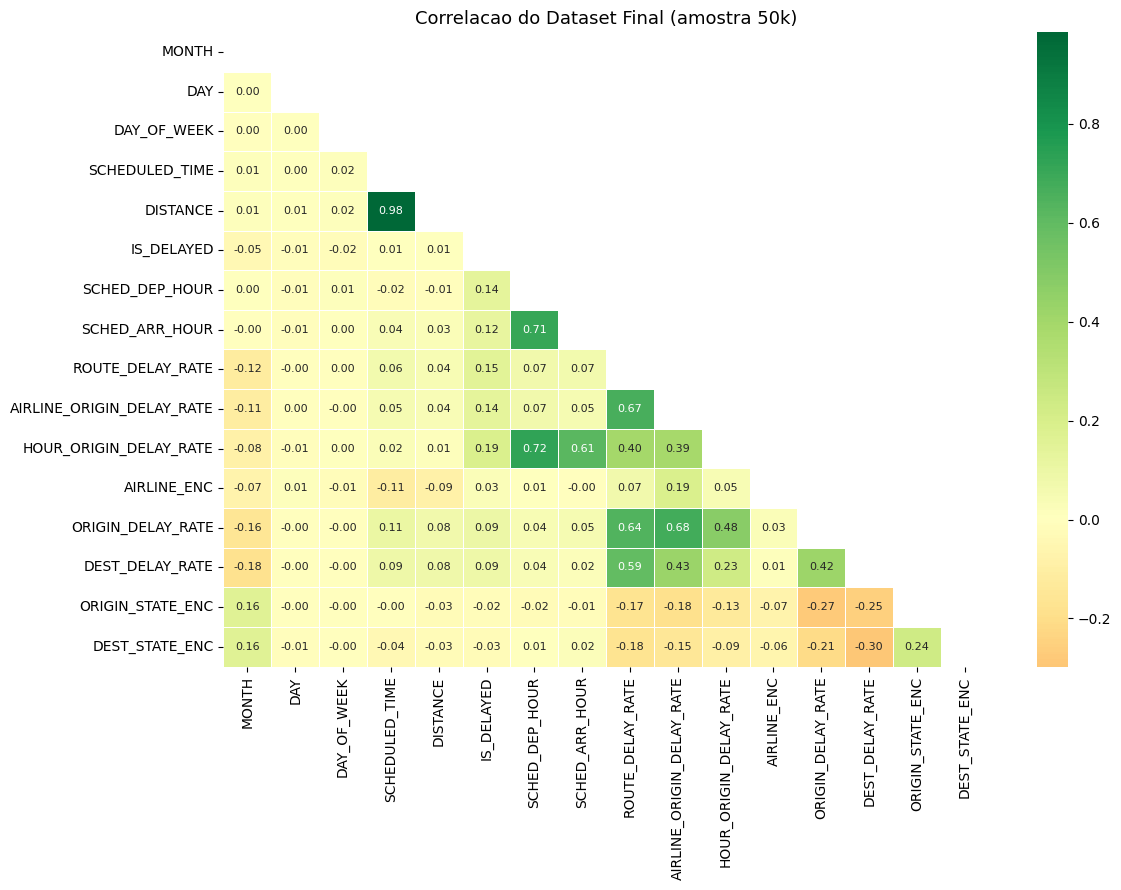

In [15]:
# Heatmap de correlacao do dataset final
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones(df.shape[1], dtype=bool))
corr = df.sample(50000, random_state=42).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlacao do Dataset Final (amostra 50k)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Salvar Dataset em data/refined/

In [16]:
output_path = '../data/refined/flights_features.csv'
os.makedirs('../data/refined/', exist_ok=True)

df.to_csv(output_path, index=False)

file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f'Dataset salvo em: {output_path}')
print(f'Tamanho:  {file_size_mb:.1f} MB')
print(f'Linhas:   {len(df):,}')
print(f'Colunas:  {len(df.columns)}')
print(f'\nPrimeiras linhas:')
df.head()

Dataset salvo em: ../data/refined/flights_features.csv
Tamanho:  709.1 MB
Linhas:   5,714,008
Colunas:  16

Primeiras linhas:


,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_TIME,DISTANCE,IS_DELAYED,SCHED_DEP_HOUR,SCHED_ARR_HOUR,ROUTE_DELAY_RATE,AIRLINE_ORIGIN_DELAY_RATE,HOUR_ORIGIN_DELAY_RATE,AIRLINE_ENC,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ORIGIN_STATE_ENC,DEST_STATE_ENC
0,1,1,4,205.0,1448,0,0,4,0.106648,0.106005,0.093927,1,0.125680,0.164567,0,50
1,1,1,4,280.0,2330,0,0,7,0.298701,0.167492,0.180596,0,0.209794,0.231559,5,9
2,1,1,4,286.0,2296,0,0,8,0.129763,0.132199,0.160517,11,0.202995,0.158363,5,28
3,1,1,4,285.0,2342,0,0,8,0.211859,0.167492,0.180596,0,0.209794,0.207498,5,9
4,1,1,4,235.0,1448,0,0,3,0.179487,0.147512,0.123438,1,0.168400,0.176370,50,0
